# Objeto Abasy

In [2]:
import math
from math import log
import networkx as nx
from freyrelab.nets import models
from freyrelab.regnets import regnet
from freyrelab.regnets.abasy import Abasy

In [3]:
# start instance of Abasy
abasy = Abasy(db='abasy_internal', expire_cache=True)
regnet_ids = abasy.select_regnets(nr_strong_wa=True) # select all regnets withour redundancy, keep the strong one if available
# regnet_ids = abasy.select_regnets('511145', strong=True) # select all regnets withour redundancy, keep the strong one if available
regnets = abasy.regnet(regnet_ids) # get the regnets {regnet_id: regnet}

In [6]:
regnets['100226_v2019_sA22-DBSCR15_eStrong'].edges()

OutEdgeView([('SCO1489', 'SCO2817'), ('SCO1489', 'SCO1489'), ('SCO1489', 'SCO3323'), ('SCO1489', 'sigH'), ('SCO1489', 'SCO2792'), ('SCO1489', 'SCO3328'), ('SCO1489', 'whiG'), ('SCO1489', 'SCO7337'), ('SCO1489', 'SCOt24'), ('SCO1489', 'ftsZ'), ('SCO1489', 'sti1'), ('SCO4596', 'bfr'), ('SCO4596', 'SCO4596'), ('SCO4596', 'SCO3328'), ('SCO4596', 'SCO6809'), ('SCO4596', 'SCO6992'), ('SCO4596', 'SCO0736'), ('SCO4596', 'actII-4'), ('SCO2964', 'SCO2964'), ('SCO1480', 'actII-4'), ('SCO1480', 'redD'), ('SCO3063', 'SCO2026'), ('SCO3063', 'SCO2833'), ('SCO3063', 'SCO2014'), ('SCO3063', 'SCO6198'), ('SCO3063', 'SCO6706'), ('SCO3063', 'SCO6222'), ('SCO3063', 'SCO7336'), ('SCO3063', 'SCO3139'), ('SCO3063', 'SCO0072'), ('SCO3063', 'SCO1147'), ('SCO3063', 'SCO1753'), ('SCO3063', 'SCO6705'), ('SCO3063', 'SCO5393'), ('SCO3063', 'SCO4883'), ('SCO3063', 'SCO6748'), ('SCO3063', 'SCO7337'), ('SCO3063', 'SCO6280'), ('SCO3063', 'actII-4'), ('SCO5405', 'SCO7681'), ('SCO5405', 'SCO7682'), ('SCO5405', 'SCO2183'),

# Network models

In [3]:
## You may still optimize this

# def find_closest_approximation(x):
#     closest_diff = float('inf')
#     closest_m = None
#     closest_n = None

#     for m in range(3, x+1): # m is the base, start from 3
#         n = math.floor(math.log(x, m))
#         approx = m ** n

#         # not greater than x
#         if approx <= x:
#             diff = x - approx

#             if diff < closest_diff:
#                 closest_diff = diff
#                 closest_m = m
#                 closest_n = n

#     return closest_m, closest_n


In [5]:
seed = 42
random_graph = {}

i = 0
hm_seed_size = 3
for net_id, G in regnets.items():
    n = G.number_of_nodes()
    m = G.number_of_edges()
    random_graph[f'BA_{net_id}'] = models.barabasi_albert_graph(n)
    random_graph[f'SF_{net_id}'] = nx.scale_free_graph(n, seed=seed)
    random_graph[f'ER_{net_id}'] = nx.erdos_renyi_graph(n, m/(n*(n-1)), seed=seed, directed=True)
    random_graph[f'HM_{net_id}'] = models.hierarchical_modular_graph(int(log(n, hm_seed_size))-1, m=hm_seed_size)
    # hm_seed_size, iterations = find_closest_approximation(n)
    # random_graph[f'HM_{net_id}'] = models.hierarchical_modular_graph(n=iterations, m=hm_seed_size)
    i += 1
    print(i/len(regnets), net_id, flush=True)


0.023809523809523808 100226_v2019_sA22-DBSCR15_eStrong
0.047619047619047616 158878_v2015_sRTB13
0.07142857142857142 158879_v2015_sRTB13
0.09523809523809523 160491_v2015_sRTB13
0.11904761904761904 186103_v2015_sRTB13
0.14285714285714285 196620_v2015_sRTB13
0.16666666666666666 196627_v2020_s21_eStrong
0.19047619047619047 198466_v2015_sRTB13
0.21428571428571427 199310_v2015_sRTB13
0.23809523809523808 208964_v2020_sRPA20_eStrong
0.2619047619047619 224308_v2008_sDBTBS08_eStrong
0.2857142857142857 273036_v2015_sRTB13
0.30952380952380953 282458_v2015_sRTB13
0.3333333333333333 282459_v2015_sRTB13
0.35714285714285715 301447_v2015_sRTB13
0.38095238095238093 316385_v2015_sRTB13
0.40476190476190477 319701_v2015_sRTB13
0.42857142857142855 331111_v2015_sRTB13
0.4523809523809524 331112_v2015_sRTB13
0.47619047619047616 340184_v2015_sRTB13
0.5 344601_v2015_sRTB13
0.5238095238095238 359786_v2015_sRTB13
0.5476190476190477 359787_v2015_sRTB13
0.5714285714285714 362663_v2015_sRTB13
0.5952380952380952 36410

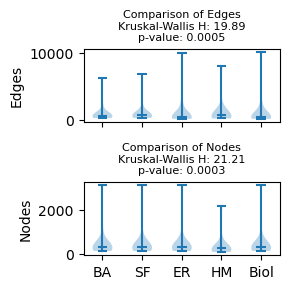

In [8]:
import numpy as np
from scipy.stats import kruskal
import matplotlib.pyplot as plt

labels=['BA', 'SF', 'ER', 'HM', 'Biol']

ba_edges = [v.number_of_edges() for k, v in random_graph.items() if k.startswith('BA')]
sf_edges = [v.number_of_edges() for k, v in random_graph.items() if k.startswith('SF')]
er_edges = [v.number_of_edges() for k, v in random_graph.items() if k.startswith('ER')]
hm_edges = [v.number_of_edges() for k, v in random_graph.items() if k.startswith('HM')]
biol_edges = [v.number_of_edges() for k, v in regnets.items()]

ba_nodes = [v.number_of_nodes() for k, v in random_graph.items() if k.startswith('BA')]
sf_nodes = [v.number_of_nodes() for k, v in random_graph.items() if k.startswith('SF')]
er_nodes = [v.number_of_nodes() for k, v in random_graph.items() if k.startswith('ER')]
hm_nodes = [v.number_of_nodes() for k, v in random_graph.items() if k.startswith('HM')]
biol_nodes = [v.number_of_nodes() for k, v in regnets.items()]

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(3,3))

# Plot the violin plot for edges
edges_dist = [ba_edges, sf_edges, er_edges, hm_edges, biol_edges]
statistic, p_value = kruskal(*edges_dist)
ax1.violinplot(edges_dist, showmedians=True)
ax1.set_ylabel('Edges')
ax1.set_title('\n'.join(['Comparison of Edges',f"Kruskal-Wallis H: {statistic:.2f}", f"p-value: {p_value:.4f}"]), fontsize=8)
ax1.set_xticks(np.arange(1, len(labels) + 1))
ax1.set_xticklabels(labels)

# Plot the violin plot for nodes
nodes_dist = [ba_nodes, sf_nodes, er_nodes, hm_nodes, biol_nodes]
statistic, p_value = kruskal(*nodes_dist)
ax2.violinplot(nodes_dist, showmedians=True)
ax2.set_ylabel('Nodes')
ax2.set_title('\n'.join(['Comparison of Nodes',f"Kruskal-Wallis H: {statistic:.2f}", f"p-value: {p_value:.4f}"]), fontsize=8)
ax2.set_xticks(np.arange(1, len(labels) + 1))
ax2.set_xticklabels(labels)

# Adjust spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


## API

In [1]:
foo = 'https://abasy.ccg.unam.mx:7169/rest/regnets/{regned_id}?field=Regnet&format=tsv'

In [1]:
import requests

def get_regnet(regnet_id, format='json'):
    url = f'https://abasy.ccg.unam.mx/rest/regnets/{regnet_id}?field=Regnet&format={format}'
    response = requests.get(url)
    return response.json() if format == 'json' else response.text

regnet_id = '511145_v2005_sRDB04'
regnet = get_regnet(regnet_id, format='tsv')
print(regnet)

<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">
<html><head>
<title>403 Forbidden</title>
</head><body>
<h1>Forbidden</h1>
<p>You don't have permission to access this resource.</p>
<p>Additionally, a 403 Forbidden
error was encountered while trying to use an ErrorDocument to handle the request.</p>
</body></html>



In [ ]:
# from scipy import stats
# from collections import Counter
# from freyrelab.nets import models

# # graph
# coli = abasy.regnet('511145_v2011_sRDB11')

# # degree distribution (histogram)
# ks = [k for k,_ in coli.k_clustering().values()]
# xk = sorted(set(ks))
# pk = [Counter(ks)[k]/len(ks) for k in xk]
# dist = stats.rv_discrete(values=(xk, pk))

# # barabasi_albert_graph
# foo = models.barabasi_albert_graph(n=coli.number_of_nodes(), m=dist)